# Phase 2: Data Wrangling & Exploratory Data Analysis
This notebook performs a full data audit, applies cleaning decisions, handles outliers using IQR and Z-score methods, and produces 8 visualizations.


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [58]:
# Load Steam-200k
steam200k_path = '../data/raw/steam-200k/steam-200k.csv'
cols = ['user_id', 'game_title', 'behavior', 'hours_played', '0']
df_200k = pd.read_csv(steam200k_path, header=None, names=cols)

# Filter for only 'play' behavior, as 'purchase' doesn't give us hours played accurately for behavior profiling
df_play = df_200k[df_200k['behavior'] == 'play'].copy()

# Load Steam Metadata
steam_metadata_path = '../data/raw/steam/steam.csv'
df_meta = pd.read_csv(steam_metadata_path)

print(f"Steam-200k Play Records Shape: {df_play.shape}")
print(f"Steam Metadata Shape: {df_meta.shape}")


Steam-200k Play Records Shape: (70489, 5)
Steam Metadata Shape: (27075, 18)


In [59]:
# --- Data Audit & Cleaning ---

# 1. Check for missing values
print("Missing values in Play Data:\n", df_play.isnull().sum())
print("\nMissing values in Metadata:\n", df_meta.isnull().sum()[df_meta.isnull().sum() > 0])

# Cleaning decisions:
# - Drop the '0' column from play data as it's useless
df_play.drop(columns=['0'], inplace=True)

# - For metadata, missing developer/publisher can be filled with 'Unknown'
df_meta['developer'] = df_meta['developer'].fillna('Unknown')
df_meta['publisher'] = df_meta['publisher'].fillna('Unknown')

# 2. Check for duplicates
print(f"\nDuplicates in Play Data: {df_play.duplicated().sum()}")
df_play.drop_duplicates(inplace=True)

print("Data Cleaning Complete.")


Missing values in Play Data:
 user_id         0
game_title      0
behavior        0
hours_played    0
0               0
dtype: int64

Missing values in Metadata:
 developer     1
publisher    14
dtype: int64

Duplicates in Play Data: 0
Data Cleaning Complete.


In [60]:
# --- Outlier Detection (IQR & Z-score) on hours_played ---

# 1. IQR Method
Q1 = df_play['hours_played'].quantile(0.25)
Q3 = df_play['hours_played'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_play[(df_play['hours_played'] < lower_bound) | (df_play['hours_played'] > upper_bound)]
print(f"Outliers detected using IQR: {len(outliers_iqr)}")

# 2. Z-Score Method
z_scores = np.abs(stats.zscore(df_play['hours_played']))
outliers_z = df_play[z_scores > 3]
print(f"Outliers detected using Z-score (>3): {len(outliers_z)}")

# Cleaning decision for outliers:
# For behavioral recommendation, extreme playtimes (e.g., 10,000+ hours) might be bots or AFK players.
# We will cap them using the 99th percentile rather than removing them completely to avoid losing passionate players.
cap_value = df_play['hours_played'].quantile(0.99)
df_play['hours_played_capped'] = np.where(df_play['hours_played'] > cap_value, cap_value, df_play['hours_played'])

print(f"Capped extreme outliers at 99th percentile: {cap_value:.2f} hours")


Outliers detected using IQR: 9994
Outliers detected using Z-score (>3): 938
Capped extreme outliers at 99th percentile: 908.00 hours


## 8 Visualizations

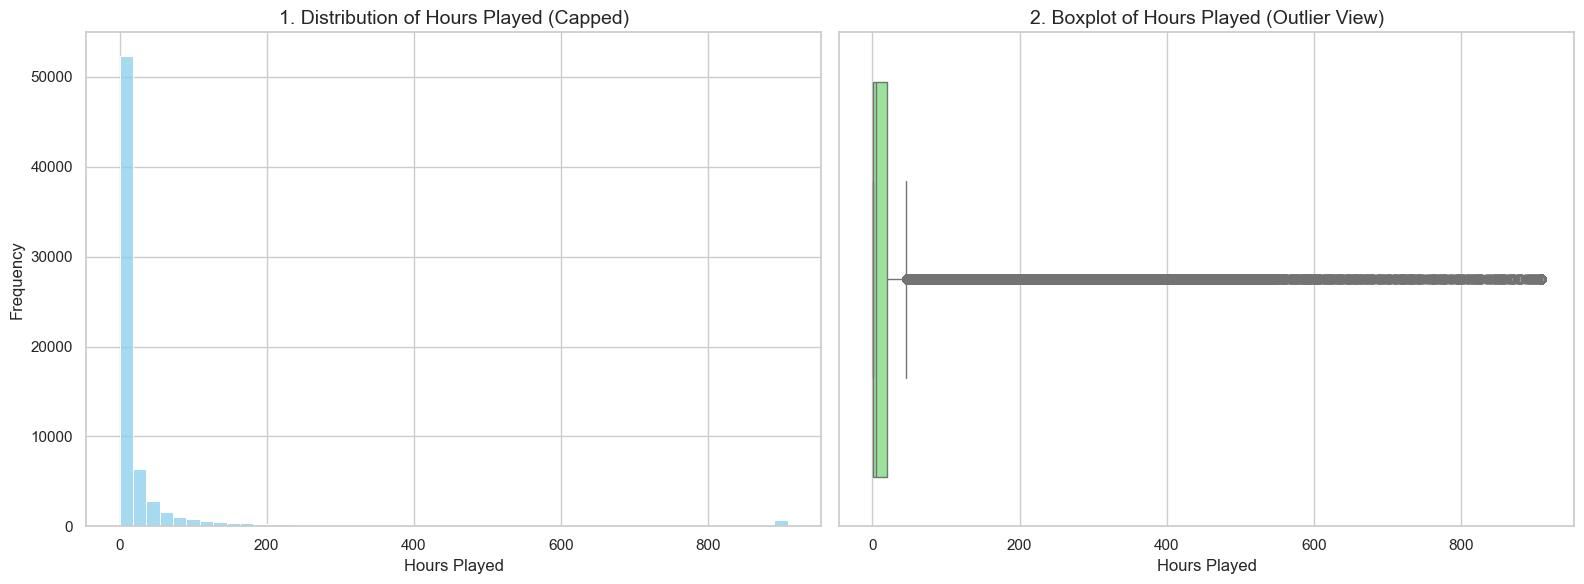

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualization 1: Distribution of hours played
sns.histplot(df_play['hours_played_capped'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('1. Distribution of Hours Played (Capped)', fontsize=14)
axes[0].set_xlabel('Hours Played')
axes[0].set_ylabel('Frequency')

# Visualization 2: Boxplot of hours played
sns.boxplot(x=df_play['hours_played_capped'], ax=axes[1], color='lightgreen')
axes[1].set_title('2. Boxplot of Hours Played (Outlier View)', fontsize=14)
axes[1].set_xlabel('Hours Played')

plt.tight_layout()
plt.show()


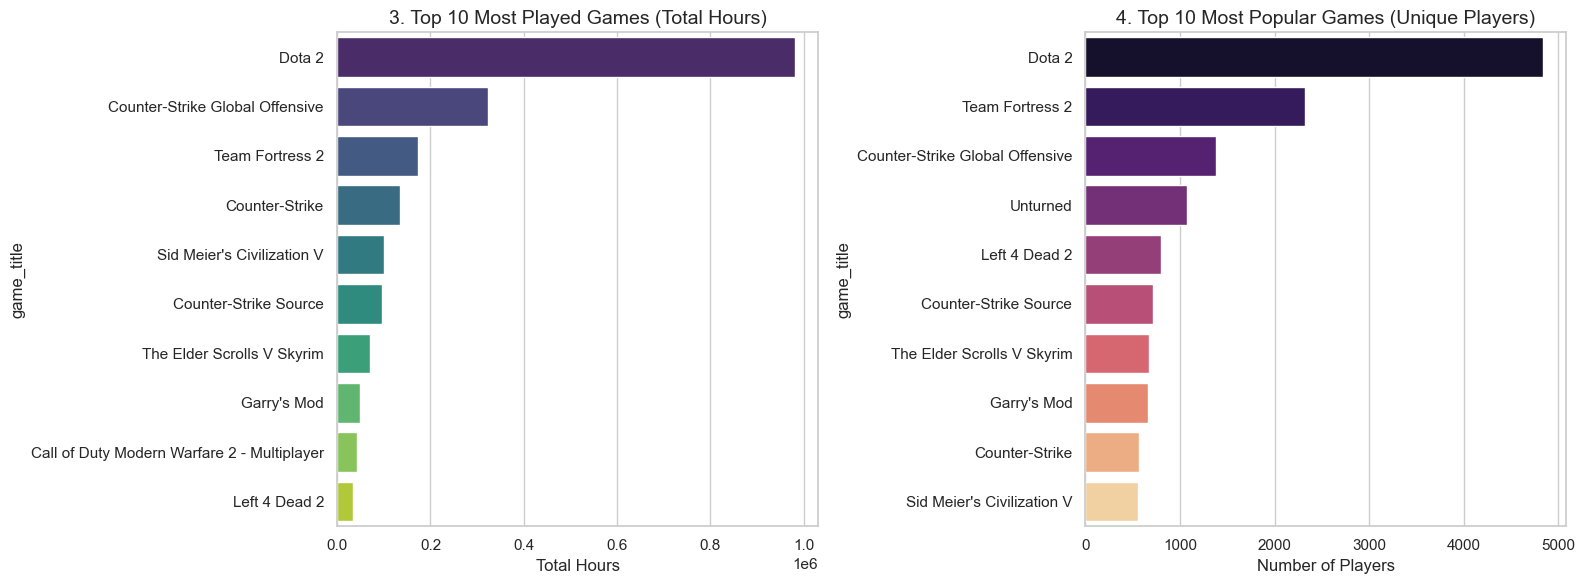

In [62]:
# Visualization 3: Top 10 most played games (by total hours)
top_played = df_play.groupby('game_title')['hours_played'].sum().sort_values(ascending=False).head(10)

# Visualization 4: Top 10 most popular games (by number of unique players)
top_popular = df_play['game_title'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(y=top_played.index, x=top_played.values, ax=axes[0], palette='viridis', hue=top_played.index, legend=False)
axes[0].set_title('3. Top 10 Most Played Games (Total Hours)', fontsize=14)
axes[0].set_xlabel('Total Hours')

sns.barplot(y=top_popular.index, x=top_popular.values, ax=axes[1], palette='magma', hue=top_popular.index, legend=False)
axes[1].set_title('4. Top 10 Most Popular Games (Unique Players)', fontsize=14)
axes[1].set_xlabel('Number of Players')

plt.tight_layout()
plt.show()


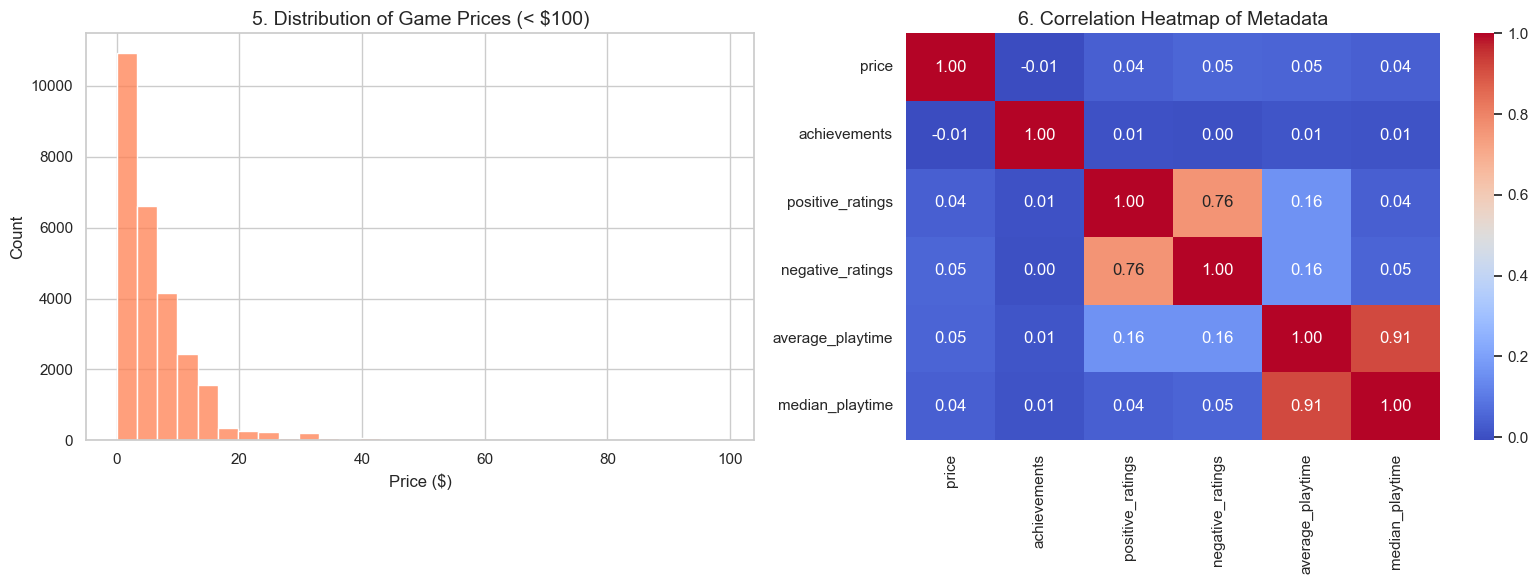

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualization 5: Distribution of game prices
sns.histplot(df_meta[df_meta['price'] < 100]['price'], bins=30, ax=axes[0], color='coral')
axes[0].set_title('5. Distribution of Game Prices (< $100)', fontsize=14)
axes[0].set_xlabel('Price ($)')

# Visualization 6: Correlation heatmap of numerical metadata
numeric_cols = ['price', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime']
corr = df_meta[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1], fmt=".2f")
axes[1].set_title('6. Correlation Heatmap of Metadata', fontsize=14)

plt.tight_layout()
plt.show()


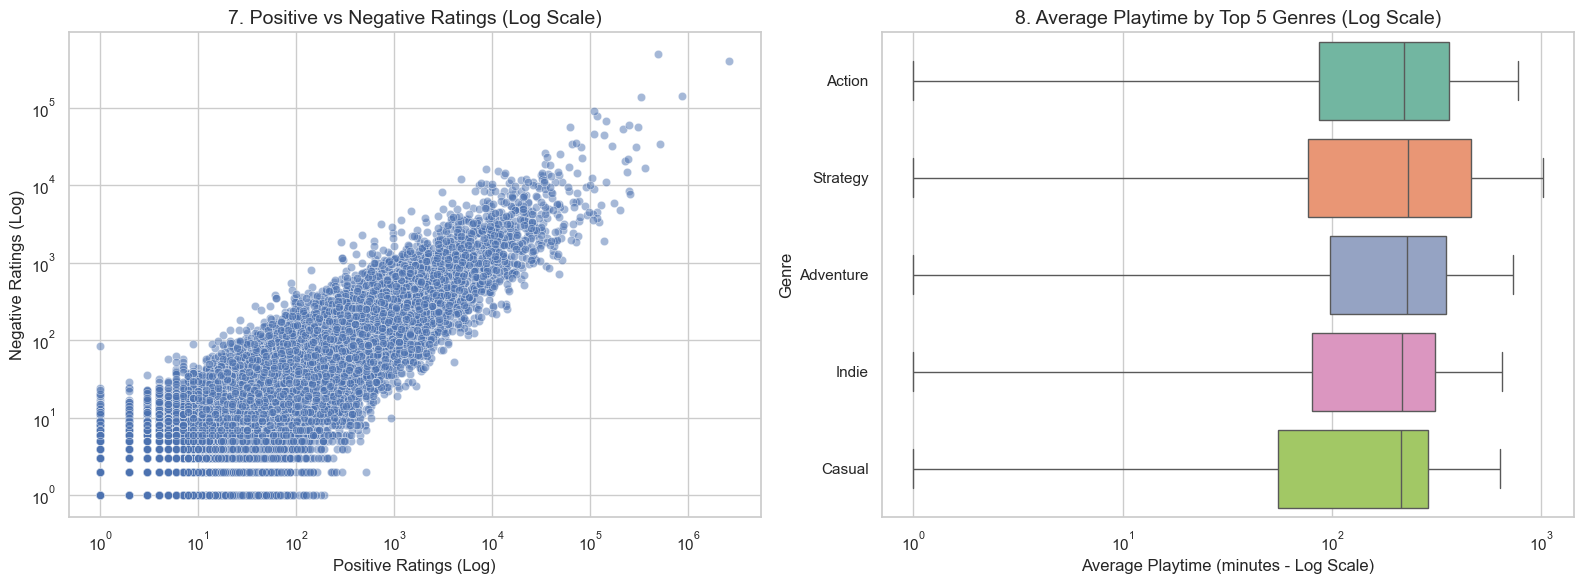

In [70]:
# Initialisation des subplots (1 ligne, 2 colonnes)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =====================================================================
# Visualization 7: Positive vs Negative Ratings (Log Scale)
# =====================================================================
df_meta['total_ratings'] = df_meta['positive_ratings'] + df_meta['negative_ratings']

sns.scatterplot(
    x='positive_ratings', 
    y='negative_ratings', 
    data=df_meta, 
    ax=axes[0], 
    alpha=0.5
)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('7. Positive vs Negative Ratings (Log Scale)', fontsize=14)
axes[0].set_xlabel('Positive Ratings (Log)')
axes[0].set_ylabel('Negative Ratings (Log)')



# =====================================================================
# Visualization 8: Playtime distribution by genre (top 5 genres)
# =====================================================================
# 1. Sécurisation et conversion stricte du type numérique
df_meta['average_playtime'] = pd.to_numeric(df_meta['average_playtime'], errors='coerce')

# 2. Isolation des colonnes nécessaires et suppression des lignes sans genre
df_genres_clean = df_meta[['average_playtime', 'genres']].dropna(subset=['genres']).copy()

# 3. Découpage par le point-virgule (le séparateur natif du dataset nikdavis) et explosion
df_genres_clean['genre'] = df_genres_clean['genres'].astype(str).str.split(';')
df_genres_clean = df_genres_clean.explode('genre').reset_index(drop=True)

# 4. Nettoyage des espaces blancs résiduels et suppression des chaînes vides
df_genres_clean['genre'] = df_genres_clean['genre'].str.strip()
df_genres_clean = df_genres_clean[df_genres_clean['genre'] != '']

# 5. Sélection des 5 genres les plus fréquents
top_genres = df_genres_clean['genre'].value_counts().head(5).index

# 6. Filtrage final du dataset (on garde le top 5 ET on exclut les temps nuls pour le log)
df_filtered_genres = df_genres_clean[
    (df_genres_clean['genre'].isin(top_genres)) & 
    (df_genres_clean['average_playtime'] > 0)
].copy()

# 7. Affichage du Boxplot
sns.boxplot(
    data=df_filtered_genres,
    x='average_playtime', 
    y='genre', 
    ax=axes[1], 
    showfliers=False,  # Optionnel maintenant que l'échelle log gère l'étalement
    hue='genre', 
    palette='Set2',
    legend=False
)

# CONFIGURATION CRUCIALE : Passage de l'axe X en échelle Logarithmique
axes[1].set_xscale('log')

# Configuration des labels et titres
axes[1].set_title('8. Average Playtime by Top 5 Genres (Log Scale)', fontsize=14)
axes[1].set_xlabel('Average Playtime (minutes - Log Scale)')
axes[1].set_ylabel('Genre')

# Optimisation et affichage final
plt.tight_layout()
plt.show()

In [9]:
# Save the cleaned and capped datasets for Phase 3 Feature Engineering
df_play.to_csv('../data/interim/steam200k_cleaned.csv', index=False)
df_meta.to_csv('../data/interim/steam_metadata_cleaned.csv', index=False)

print("Saved interim datasets successfully!")


Saved interim datasets successfully!
